<a href="https://colab.research.google.com/github/gonmpa/CRISP-DM_MD_Gonzalo_Pino/blob/main/Evaluacion_final_MD_Pino_Gonzalo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Nombre: Gonzalo Pino
###Carrera: Ingeniería Informática / Sede: IP Arica / Sección: Vespertino
###DataSet elegido: Spotify Global Music Dataset (2009–2025) / URL: https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025

### PARTE A



Fase CRISP-DM: Comprensión del Negocio (Business Understanding)

###Contexto:
El dataset seleccionado es "Spotify Global Music Dataset (2009-2025)", el cual contiene registros de pistas musicales detalladas a través de métricas comerciales de streaming, metadatos de lanzamiento y niveles de popularidad global. Este conjunto de datos está orientado a científicos de datos, analistas de la industria musical, discográficas (A&R) y estrategas de marketing. Estos profesionales pueden utilizarlo para comprender el comportamiento de los oyentes, evaluar el impacto de los artistas y predecir el éxito comercial de las canciones en plataformas de streaming.

###Objetivo (Decisión que apoya el análisis):
El objetivo central del análisis es descubrir qué combinaciones de factores (como la base de seguidores, la duración, el tipo de álbum o si el contenido es explícito) determinan la alta popularidad de una pista o definen su género musical. La decisión concreta que este análisis apoyará es la optimización de estrategias de lanzamiento y la creación de campañas de marketing musical dirigidas. Utilizaremos Árboles de Decisión para predecir el nivel de popularidad de una canción (clasificándola en Alta, Media o Baja) en función de sus características comerciales, y Reglas de Asociación para descubrir qué atributos coexisten frecuentemente en los éxitos globales (por ejemplo, descubrir si los lanzamientos tipo Single explícitos se asocian fuertemente con el género Hip-Hop y alta popularidad).

###Por qué este problema se aborda con Minería de Datos (y no con consultas simples):
Este problema exige el uso de Minería de Datos porque una simple consulta a una base de datos o el cálculo de un promedio (por ejemplo, "la popularidad promedio del Pop") es insuficiente para modelar el éxito en la industria musical actual. El éxito o el encasillamiento de una canción depende de la interacción simultánea de múltiples variables comerciales (duración, popularidad previa del artista, formato del lanzamiento). La minería de datos permite extraer patrones subyacentes complejos y generar modelos predictivos que pueden anticipar tendencias, yendo mucho más allá de la simple descripción estadística histórica.

## PARTE B

###Fase CRISP-DM: Comprensión de los Datos (Data Understanding)

####1. Fuente de los datos
Nombre del Dataset: Spotify Global Music Dataset (2009-2025)

Autor / Organización: Warda Bilal (disponible en Kaggle)

Enlace: Kaggle - Spotify Global Music Dataset

Licencia: Abierta / Uso educacional en Kaggle.

####2. Diccionario de datos (Atributos seleccionados)
A continuación se describen 10 atributos clave del dataset, su tipo de variable y su importancia para el objetivo del análisis:

2.1) track_popularity (Cuantitativa Continua / Variable Clase al discretizar): Mide
el nivel de popularidad actual de la canción en Spotify (de 0 a 100). Es fundamental porque actuará como nuestra variable objetivo (target); al convertirla en categorías (Baja, Media, Alta), el modelo aprenderá a predecir qué hace exitosa a una canción.

2.2)artist_genres (Cualitativa Nominal): Lista de géneros musicales asociados al artista. Es crucial para encontrar reglas de asociación que vinculen ciertos géneros con formatos de lanzamiento específicos o niveles de éxito.

2.3)explicit (Cualitativa Nominal / Binaria): Indica si la canción contiene lenguaje explícito (True/False). Ayuda a identificar si el contenido sin censura influye positiva o negativamente en la popularidad y en qué géneros es más frecuente.

2.4)artist_popularity (Cuantitativa Continua): Índice de popularidad global del artista. Permite evaluar si una pista tiene éxito por mérito propio o es impulsada por la fama previa de su creador.

2.5)artist_followers (Cuantitativa Continua): Cantidad total de seguidores del artista. Proporciona una medida directa del tamaño de su base de fans instalada (fanbase).

2.6)track_duration_min (Cuantitativa Continua): Duración de la canción en minutos. Es vital para analizar si la tendencia actual de canciones más cortas se correlaciona con una mayor popularidad en la era del streaming.

2.7)album_type (Cualitativa Nominal): Formato del lanzamiento (ej. album, single, compilation). Permite descubrir mediante reglas de asociación si los singles tienen más probabilidad de ser éxitos inmediatos que las pistas dentro de un álbum completo.

2.8)album_total_tracks (Cuantitativa Discreta): Número total de canciones que componen el álbum. Ayuda a entender si los discos largos diluyen la popularidad individual de las pistas.

2.9)album_release_date (Cualitativa Temporal): Fecha en que se lanzó el álbum. Aunque debe preprocesarse para extraer el año o mes, es clave para identificar patrones de estacionalidad (ej. canciones lanzadas en verano).

2.10)track_name (Cualitativa Nominal / Identificador): Título de la canción. Sirve para identificar los registros durante la exploración de datos, aunque se excluirá en la fase de modelado para evitar sobreajuste.

In [2]:
import pandas as pd
import io
from google.colab import files

# 1. Carga del dataset desde el PC (abre ventana de selección)
print("Por favor, selecciona tu archivo CSV del dataset de Spotify desde tu PC:")
uploaded = files.upload()

# Detecta el nombre del archivo subido y lo lee en un DataFrame de Pandas
nombre_archivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nombre_archivo]))

# 2. Dimensiones del dataset (filas y columnas)
print("\n--- DIMENSIONES DEL DATASET ---")
filas, columnas = df.shape
print(f"Cantidad de filas (registros): {filas}")
print(f"Cantidad de columnas (variables): {columnas}\n")

# 3. Vista de las primeras filas
print("--- VISTA DE LAS PRIMERAS FILAS ---")
display(df.head())

Por favor, selecciona tu archivo CSV del dataset de Spotify desde tu PC:


Saving spotify_data clean.csv to spotify_data clean.csv

--- DIMENSIONES DEL DATASET ---
Cantidad de filas (registros): 8582
Cantidad de columnas (variables): 15

--- VISTA DE LAS PRIMERAS FILAS ---


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


### PARTE C

###Fase CRISP-DM: Preparación de los datos (Data Preparing)



ESTRUCTURA Y TIPOS DE DATOS

In [3]:

print("=== 1. ESTRUCTURA Y TIPOS DE DATOS ===")

df.info()

=== 1. ESTRUCTURA Y TIPOS DE DATOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), floa

Mostramos el contenido del tipo datos, su id, el dtype y a cantidad no nulas (de las filas o instancias) de columnas de la tabla.

VALORES NULOS Y FILAS REPETIDAS

In [4]:

print("=== 2. VALORES NULOS Y DUPLICADOS ===")
nulos = df.isnull().sum()
print("Valores nulos por columna:\n", nulos[nulos > 0])

duplicados = df.duplicated().sum()
print(f"\nCantidad de filas duplicadas en el dataset: {duplicados}")

=== 2. VALORES NULOS Y DUPLICADOS ===
Valores nulos por columna:
 artist_name         3
artist_genres    3361
dtype: int64

Cantidad de filas duplicadas en el dataset: 0


Acá comprobamos que existen únicamente dos columnas con valores nulos: 3 registros sin nombre de artista (artist_name) y 3.361 registros sin género musical (artist_genres). Este hallazgo de calidad es crucial para el modelado: al identificar estos nulos en la variable de género, determinamos que los registros afectados no pueden usarse directamente en el entrenamiento supervisado del Árbol de Decisión. No obstante, esto nos abre una oportunidad analítica: podemos entrenar nuestro modelo con los registros limpios restantes y, posteriormente, utilizar el Árbol de Decisión para predecir e imputar (completar) los géneros faltantes de esas 3.361 canciones, o bien evaluar si es estadísticamente viable descartarlas sin sesgar la muestra global.



ESTADÍSTICA DESCRIPTIVA

In [5]:

print("=== 3. ESTADÍSTICA DESCRIPTIVA ===")

display(df.describe(include='all'))

=== 3. ESTADÍSTICA DESCRIPTIVA ===


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
count,8582,8582,8582.000000,8582.000000,8582,8579,8582.000000,8.582000e+03,5221,8582,8582,8582,8582.000000,8582,8582.000000
unique,8582,7462,NaN,NaN,2,2547,NaN,NaN,661,5205,4870,2384,NaN,3,NaN
top,61GEP8lryEfcuEgBMbRmNi,Flowers,NaN,NaN,False,Taylor Swift,NaN,NaN,soundtrack,3FFGbUutKWN1c4f0CJR4Uh,Nevermind (Super Deluxe Edition),2010-01-01,NaN,album,NaN
freq,1,8,NaN,NaN,6434,324,NaN,NaN,345,70,70,76,NaN,5856,NaN
mean,NaN,NaN,5.772547,52.356211,NaN,NaN,69.730016,2.403472e+07,NaN,NaN,NaN,NaN,13.789443,NaN,3.492805
std,NaN,NaN,6.052792,23.816076,NaN,NaN,19.645979,3.803180e+07,NaN,NaN,NaN,NaN,11.887131,NaN,1.057970
min,NaN,NaN,1.000000,0.000000,NaN,NaN,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,1.000000,NaN,0.070000
25%,NaN,NaN,1.000000,39.000000,NaN,NaN,60.000000,4.623200e+05,NaN,NaN,NaN,NaN,6.000000,NaN,2.880000
50%,NaN,NaN,4.000000,58.000000,NaN,NaN,74.000000,6.105547e+06,NaN,NaN,NaN,NaN,13.000000,NaN,3.445000
75%,NaN,NaN,9.000000,71.000000,NaN,NaN,84.000000,2.725255e+07,NaN,NaN,NaN,NaN,17.000000,NaN,3.990000


VISUALIZACION EDA

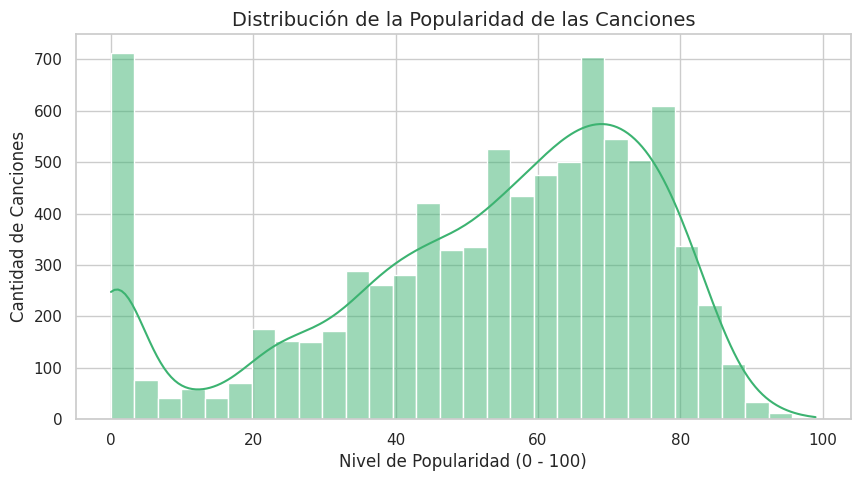

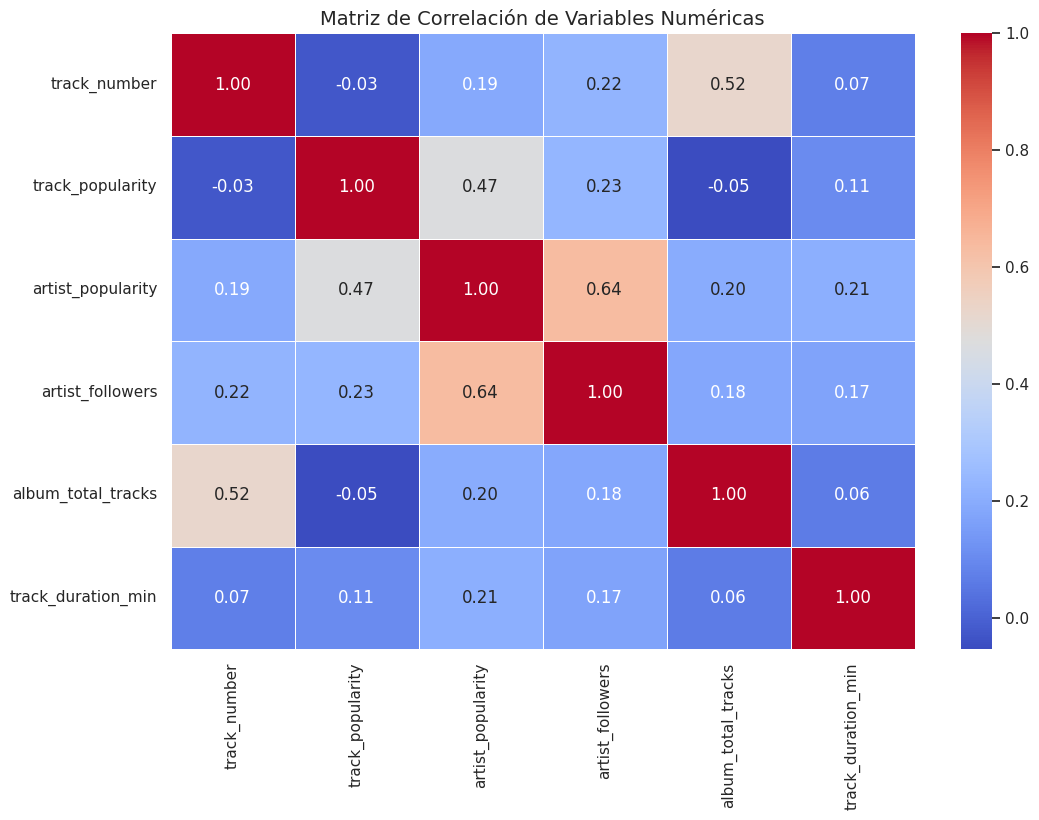

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 5))

sns.histplot(df['track_popularity'].dropna(), kde=True, color='mediumseagreen', bins=30)
plt.title('Distribución de la Popularidad de las Canciones', fontsize=14)
plt.xlabel('Nivel de Popularidad (0 - 100)')
plt.ylabel('Cantidad de Canciones')
plt.show()


plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14)
plt.show()